# Lancoz Algorithm, Ground-State: Heisenberg model

> **Code based on the official NetKet tutorial:**
> G. Carleo and F. Vicentini, *Ground-State: Heisenberg model*, NetKet Tutorials. 
> [Online]. Available: [https://netket.readthedocs.io/en/latest/tutorials/gs-heisenberg.html](https://netket.readthedocs.io/en/latest/tutorials/gs-heisenberg.html)

In [1]:
import tqdm as tqdm
import netket as nk
import jax
import jax.numpy as jnp
import time
import os
import sys

/Users/user/Desktop/EPFL/MA2/TPIV/project-tp/.env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


∣NK⟩ Tip: Debug multi-node HPC? `djaxrun -np 2 python Examples/Sharding/multi_process.py`

In [2]:
verbose = True

In [3]:
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../..')))
%load_ext autoreload
%autoreload 2

from src.lancoz_alpha_opt import lanczos_ansatz, _logpsi_lanczos
from src.utils import *
from src.plot.plotlib import *
from src.ener_landscape import *

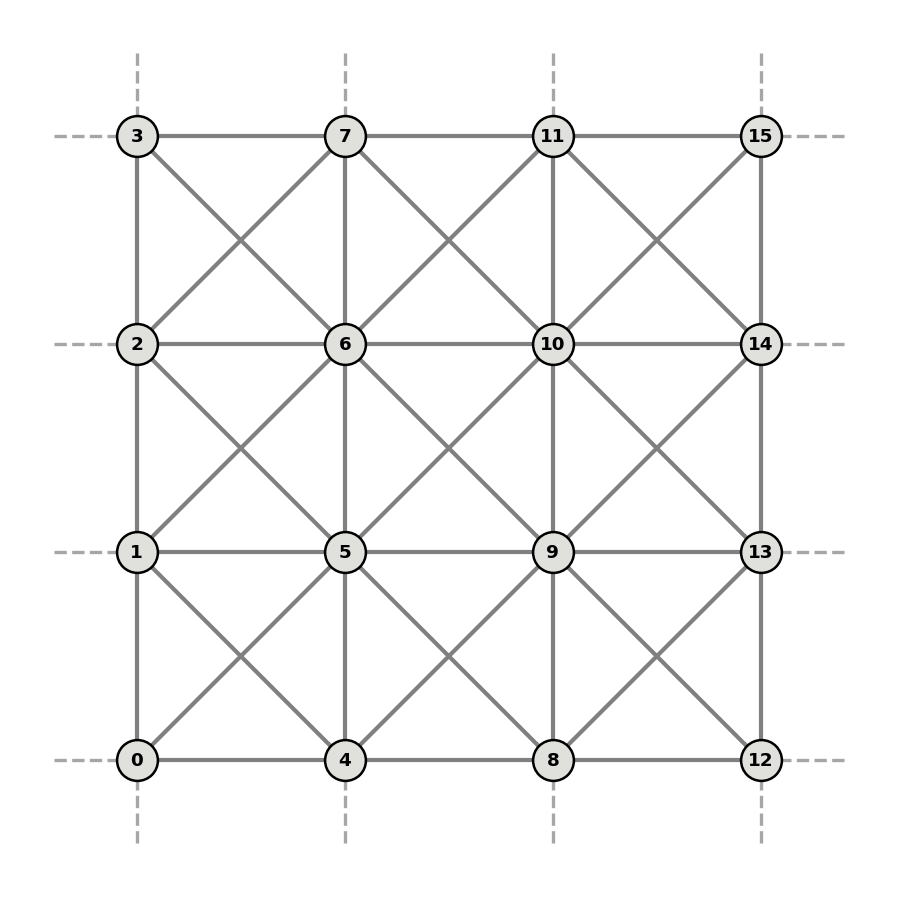

In [4]:
# Defining the Hamiltonian 
L = 4
graph = nk.graph.Hypercube(length=L, n_dim=2, pbc=True, max_neighbor_order=2) # correspond a J2 = 0
hi = nk.hilbert.Spin(s=0.5, total_sz=0, N=graph.n_nodes)
ha = 0.25 * nk.operator.Heisenberg(hilbert=hi, graph=graph, sign_rule=[True, False], J =[1.0, 0.5]) # correspond a J2 = 0
plot_netket_graph(graph, layout='square_pbc')

The exact ground-state energy is E0 = -8.457923351394848
The exact ground-state energy per site is E0/N = -0.528620209462178
(12870, 1)


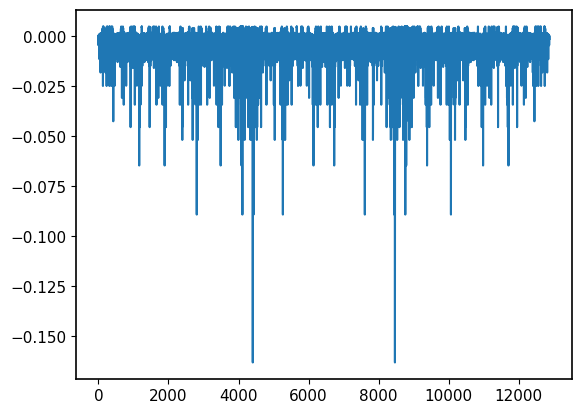

In [5]:
# Exact Diagonalization
evals, eigenstaes = nk.exact.lanczos_ed(ha, k=1, compute_eigenvectors=True)
exact_gs_energy = evals[0]
if verbose:
    print("The exact ground-state energy is E0 =", exact_gs_energy)
    print("The exact ground-state energy per site is E0/N =", exact_gs_energy/graph.n_nodes)

plt.plot(eigenstaes[:,0])
print(eigenstaes.shape)

In [6]:
# hyperparameters for the VMC optimization
diag_shift = 1e-4                       # The diagonal regularization parameter
learning_rate = 1e-2                    # learning rate
n_samples = 2048                        # number of samples
n_iter = 600                            # number of iterations (reduce # of ti to see impvoement of lancoz)
alpha = 1                               # feature density. Number of features equal to alpha * input.shape[-1]

# data directory
data_file = f"../../datas/2D_4x4_frustrated/datas_alpha_iter_{n_iter}"
dir_init = data_file + "/RBM_VMC"

# hyperparameters for the alpha optimization
lr_alpha = 1e-2                         # learning rate for the alpha optimization
n_iter_alpha = 300                      # number of iterations for the alpha optimization
dir_alpha = data_file + "/RBM_alpha"    # directory to save the results of the alpha optimization
alpha_init = 0.5                        # initial value of alpha for the alpha optimization
num_it = 100                            # number of iterations for the lanczos ansatz

# !!! test pour num_it = 100 car ressource limites

if not os.path.exists(data_file):
    os.makedirs(data_file)
    print(f"The file {data_file}' has just been created.")
else:
    print(f"The file {data_file} already exists.")

hyperparameters = {
    "data_file": data_file,
    "dir_init": dir_init,
    "dir_alpha": dir_alpha,
    "diag_shift": diag_shift,
    "learning_rate": learning_rate,
    "n_samples": n_samples,
    "n_iter": n_iter,
    "feature_density_alpha": alpha,
    "lr_alpha": lr_alpha,
    "n_iter_alpha": n_iter_alpha,
    "alpha_init": alpha_init,
    "num_it": num_it
}
json_path = os.path.join(data_file, "hyperparameters.json")

with open(json_path, 'w') as f:
    json.dump(hyperparameters, f, indent=4) 

print(f"Paramètres sauvegardés avec succès dans {json_path}")

if verbose :
    print(f" -> diag_shift : {diag_shift}")
    print(f" -> learning rate : {learning_rate}")
    print(f" -> # samples : {n_samples}")
    print(f" -> # iterations : {n_iter}")
    print(f" -> feature density : {alpha}")

The file ../../datas/2D_4x4_frustrated/datas_alpha_iter_600 already exists.
Paramètres sauvegardés avec succès dans ../../datas/2D_4x4_frustrated/datas_alpha_iter_600/hyperparameters.json
 -> diag_shift : 0.0001
 -> learning rate : 0.01
 -> # samples : 2048
 -> # iterations : 600
 -> feature density : 1


In [8]:
# Learning with a Restricted Boltzmann Machine (RBM)
model = nk.models.RBM(alpha=alpha, param_dtype=jnp.complex128)
sampler = nk.sampler.MetropolisExchange(hilbert=hi, graph=graph)
optimizer = nk.optimizer.Sgd(learning_rate=learning_rate)
vs_init = nk.vqs.MCState(sampler, model, n_samples=n_samples)
gs = nk.driver.VMC_SR(
    hamiltonian=ha, 
    optimizer=optimizer, 
    diag_shift=diag_shift, 
    variational_state=vs_init
)
gs.run(out= dir_init, n_iter=n_iter)

Automatic SR implementation choice:  QGT


100%|██████████| 600/600 [01:22<00:00,  7.28it/s, Energy=-8.249+0.000j ± 0.015 [σ²=4.7e-01, R̂=1.004]]


(JsonLog('../../datas/2D_4x4_frustrated/datas_alpha_iter_600/RBM_VMC', mode=write, autoflush_cost=0.005)
   Runtime cost:
   	Log:    0.30907320976257324
   	Params: 0.2114100456237793,)

✅ Figure saved as ../../datas/2D_4x4_frustrated/datas_alpha_iter_600/VMC_init_metrics.png


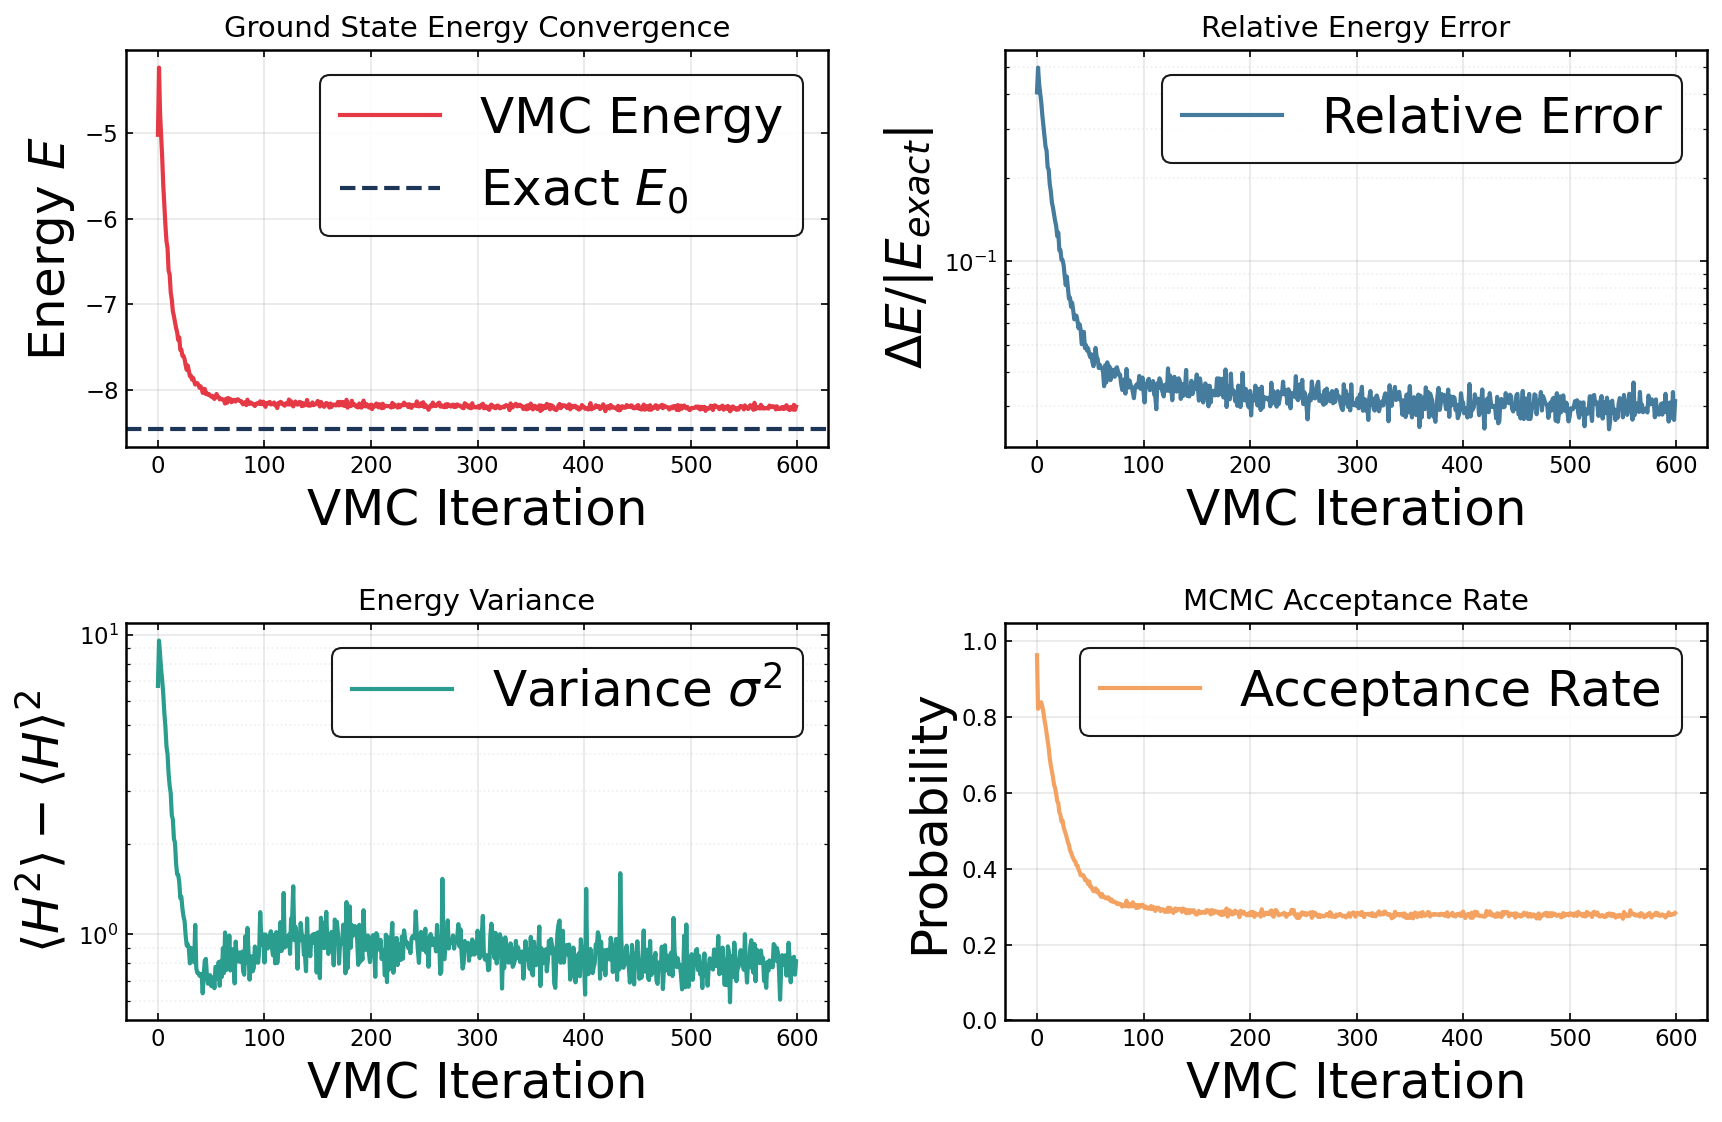

In [7]:
with open(data_file + "/RBM_VMC.log") as f:
    data = json.load(f)

if verbose:
    plot_VMC(f"{data_file}/RBM_VMC.log", exact_gs_energy, save_fig=True, fig_name=f"{data_file}/VMC_init_metrics.png")

In [9]:
# --- Hyperparamètres ---
h2 = ha @ ha
alphas_to_test = np.linspace(0.0, 0.7, 300)
N_MCMC_STEPS = 2000
N_BOOTSTRAP = 10000
SAVE_DIRECTORY = "../../assets"

print(f"Resolution of the alpha point under study: {0.7 / N_MCMC_STEPS}")

energies_mean, energies_std, e_vmc = compute_lanczos_landscape(
    vs_init=vs_init, 
    ha=ha, 
    h2=h2, 
    alphas_to_test=alphas_to_test, 
    n_mcmc_steps=N_MCMC_STEPS
)

bootstrap_results = extract_optimal_alpha_bootstrap(
    alphas_to_test=alphas_to_test, 
    energies_mean=energies_mean, 
    energies_std=energies_std, 
    n_mcmc_steps=N_MCMC_STEPS,
    n_bootstrap=N_BOOTSTRAP
)

Resolution of the alpha point under study: 0.00035


MCMC Sampling & Reweighting: 100%|██████████| 2000/2000 [1:27:51<00:00,  2.64s/it]


Running Bootstrap for Error Estimation (Smoothing: False)...


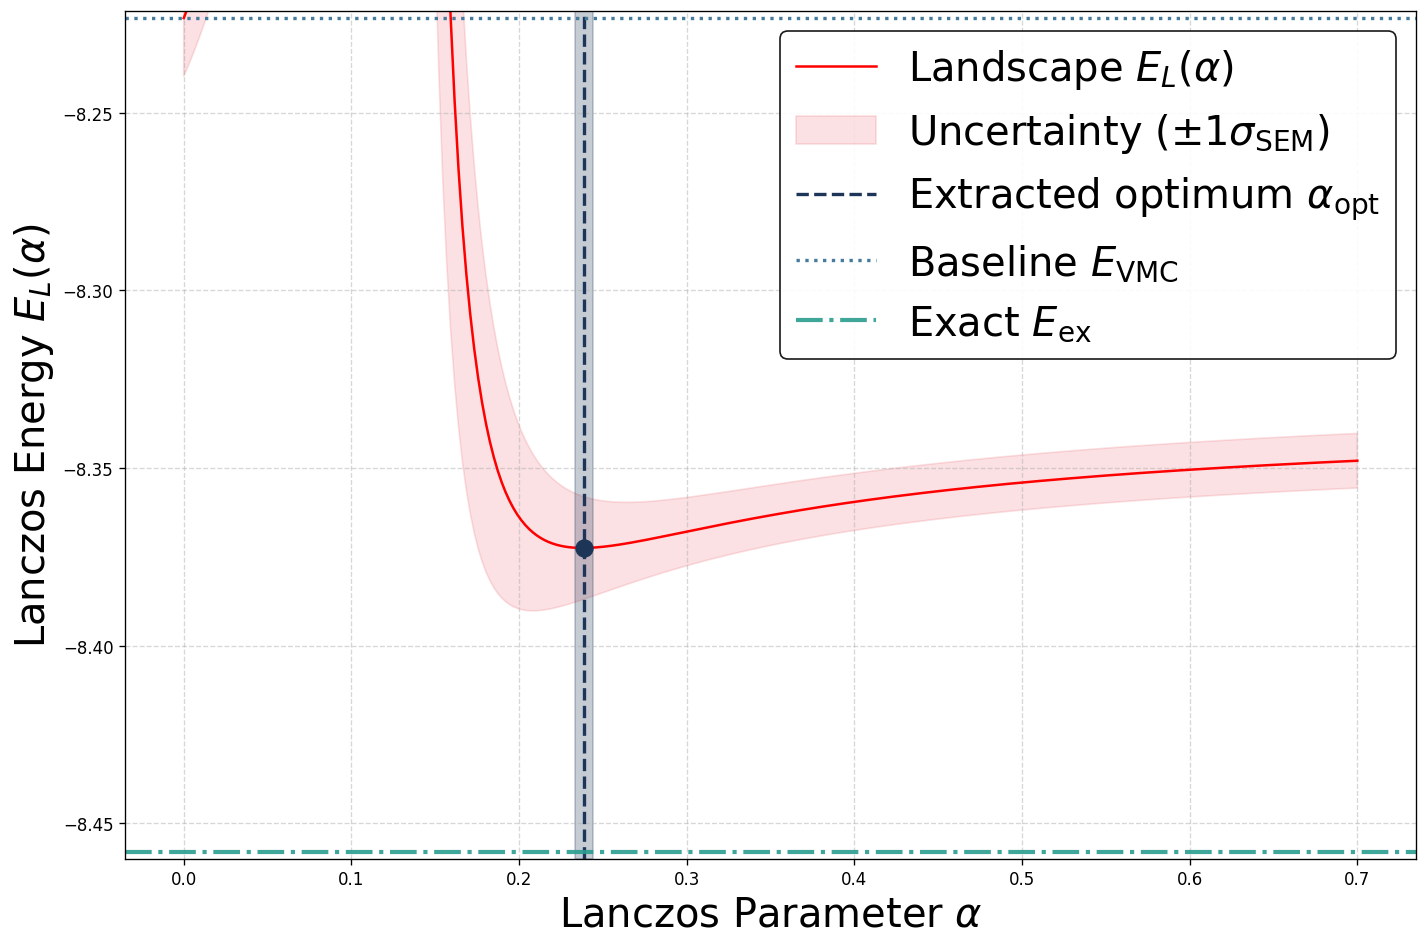

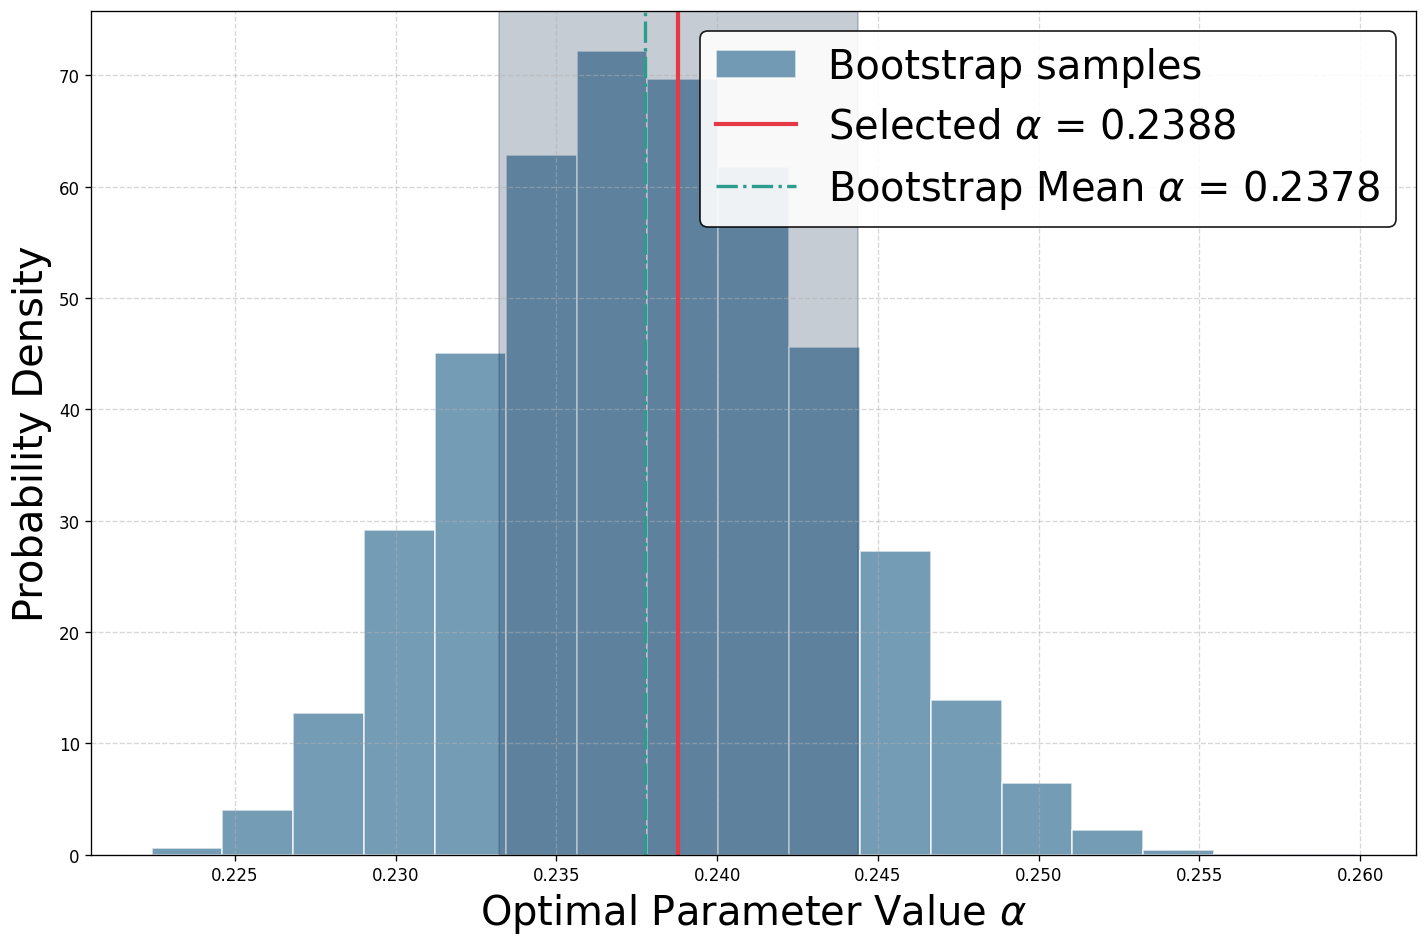

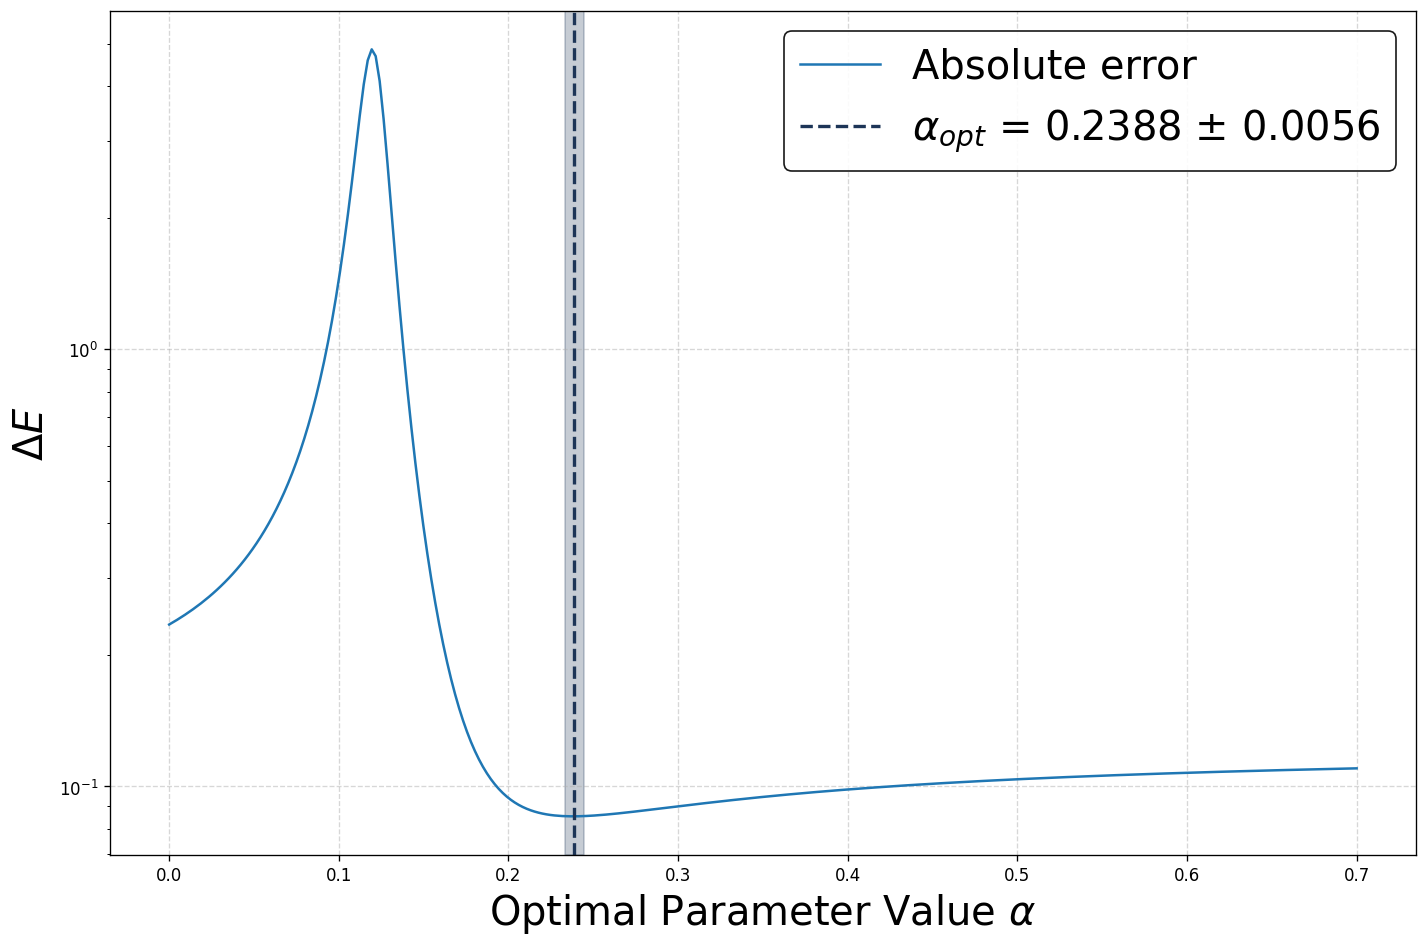


➔ EXACT MA ALPHA  : 0.23880 ± 0.00558
➔ ENERGY GAIN     : 0.14914 (VMC: -8.2233 ➔ Lanczos: -8.3725)


In [25]:
plot_lanczos_results(
    alphas_to_test=alphas_to_test, 
    energies_mean=energies_mean, 
    energies_std=energies_std, 
    e_vmc=e_vmc, 
    exact_gs_energy=exact_gs_energy, 
    bootstrap_results=bootstrap_results, 
    save_dir=data_file
)

In [11]:
afun_original = lambda x: vs_init._apply_fun(vs_init.variables, x) # Figer l'ancienne RBM (Le monde statique)

lanczos_model = lanczos_ansatz(alpha_init=alpha_init, dtype=jnp.complex128)

dummy_logpsi = jnp.zeros((1,), dtype=jnp.complex128)
dummy_eloc = jnp.zeros((1,), dtype=jnp.complex128) # donnee manequin pour init eloc (jutse donner la taille)

key = jax.random.PRNGKey(0)
lanczos_variables = lanczos_model.init(key, dummy_logpsi, dummy_eloc) # lanczos_variables contient UNIQUEMENT {'params': {'alpha': 0.01}}

apply_lanczos = nk.jax.HashablePartial(
    _logpsi_lanczos, afun_original, ha
)

vstate_lanczos = nk.vqs.MCState(
    sampler=vs_init.sampler,
    apply_fun=apply_lanczos,
    n_samples=vs_init.n_samples,
    variables=lanczos_variables, 
    n_discard_per_chain=vs_init.n_discard_per_chain, # Nombre d'échantillons à jeter par chaîne (thermalisation)
)

print("Variables de l'état :", vstate_lanczos.variables)

Variables de l'état : {'params': {'alpha': Array([0.5+0.j], dtype=complex128)}}


In [26]:
def track_alpha(step, log_data, driver):
    """
    Cette fonction est appelée par NetKet à CHAQUE itération.
    - step : le numéro de l'itération
    - driver : l'objet VMC qui contient tout notre état
    """
    valeur_alpha = driver.state.variables['params']['alpha']
    alpha_reel = valeur_alpha.real.item()
    alpha_img = valeur_alpha.imag.item()
    historique_alpha_real.append(alpha_reel)
    historique_alpha_img.append(alpha_img)
    
    return True

optimizer = nk.optimizer.Sgd(learning_rate=lr_alpha)
historique_alpha_real = []
historique_alpha_img = []
gs = nk.driver.VMC_SR(
    hamiltonian=ha, 
    optimizer=optimizer, 
    diag_shift=False, 
    variational_state=vstate_lanczos
)
gs.run(n_iter=n_iter_alpha, out= dir_alpha, callback=track_alpha)

Automatic SR implementation choice:  QGT


100%|██████████| 300/300 [16:54<00:00,  3.38s/it, Energy=-8.365-0.009j ± 0.013 [σ²=3.3e-01, R̂=1.003]]   


(JsonLog('../../datas/2D_4x4_frustrated/datas_alpha_iter_600/RBM_alpha', mode=write, autoflush_cost=0.005)
   Runtime cost:
   	Log:    0.2392103672027588
   	Params: 0.14636850357055664,)

✅ Figure saved as ../../datas/2D_4x4_frustrated/datas_alpha_iter_600/VMC_alpha_metrics.png


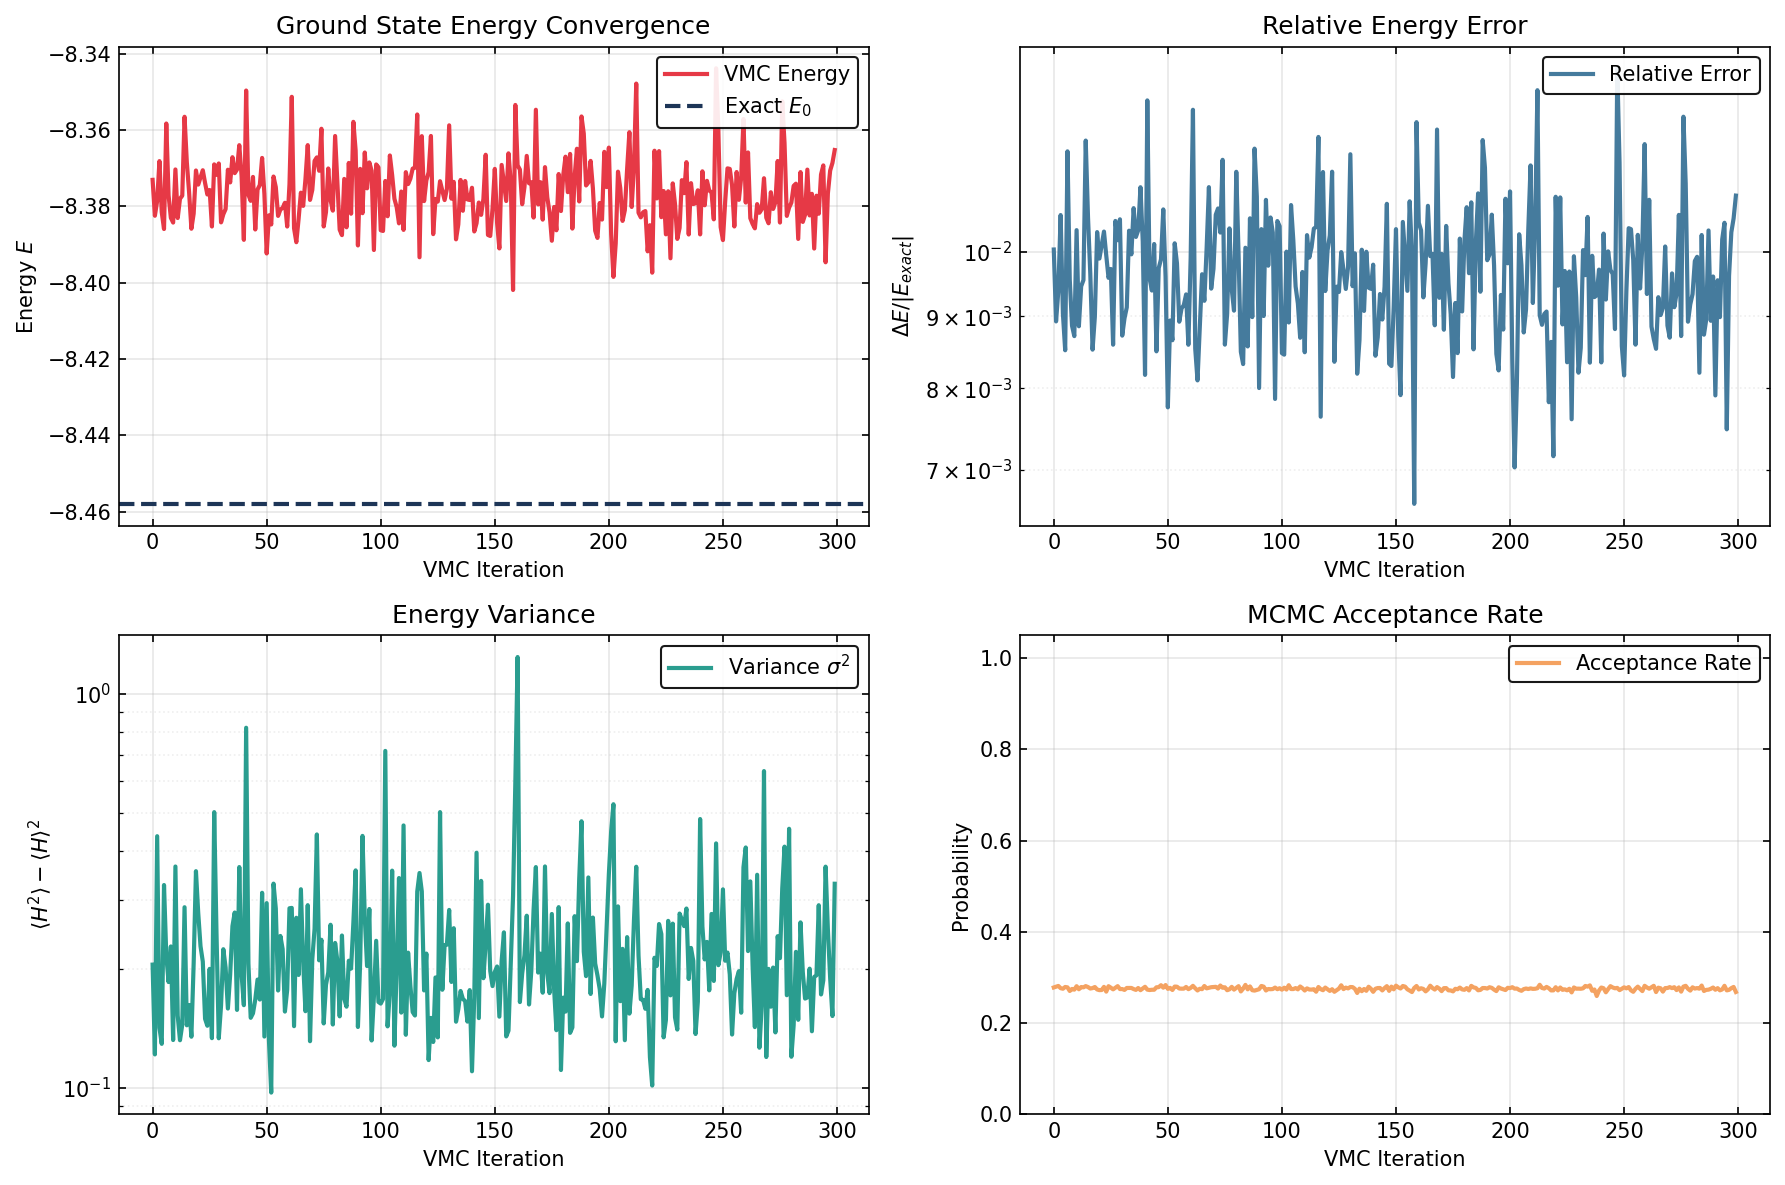

In [12]:
with open(data_file + "/RBM_alpha.log") as f:
    data = json.load(f)

if verbose:
    plot_VMC(f"{data_file}/RBM_alpha.log", exact_gs_energy, save_fig=True, fig_name=f"{data_file}/VMC_alpha_metrics.png")

✅ Figure saved as ../../datas/2D_4x4_frustrated/datas_alpha_iter_600/VMC_Sequential_metrics.png


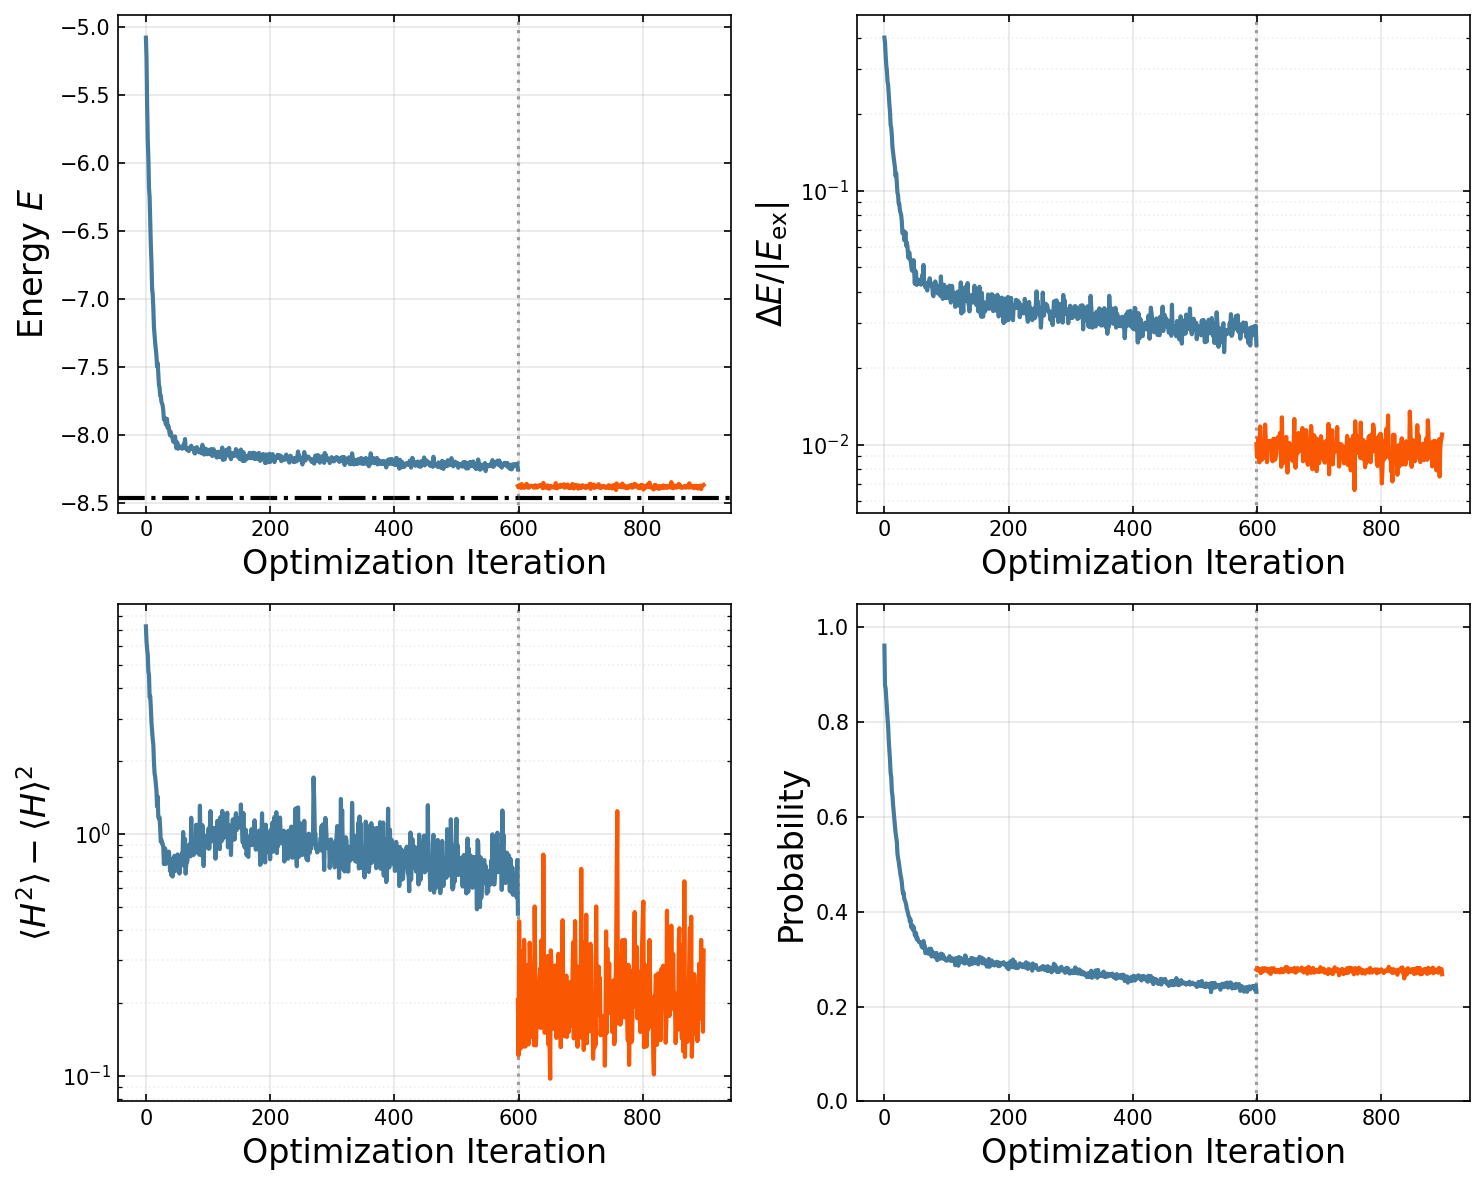

In [13]:
if verbose:
    file_init = f"{data_file}/RBM_VMC.log"
    file_alpha = f"{data_file}/RBM_alpha.log"
    
    plot_VMC_sequential(
        data_file_init=file_init,
        data_file_alpha=file_alpha,
        exact_gs_energy=exact_gs_energy,
        save_fig=True,
        fig_name=f"{data_file}/VMC_Sequential_metrics.png"
    )

In [17]:
plot_alpha_convergence(
    historique_alpha_real, 
    alpha_min=bootstrap_results["alpha_opt_final"], 
    alpha_err=bootstrap_results["alpha_opt_err"],
    data_file = data_file
)

NameError: name 'historique_alpha_real' is not defined

In [61]:
h2 = ha @ ha

results_eL = np.zeros(num_it)
results_e0 = np.zeros(num_it)
results_sigma_e0 = np.zeros(num_it) 
results_sigma_eL = np.zeros(num_it)
results_time = np.zeros(num_it) 

pbar = tqdm(range(num_it), desc="Monte Carlo Sampling")

start_time_global = time.perf_counter()

for i in pbar:

    vs_init.sample() 
    E_loc = vs_init.local_estimators(ha).real
    H2_loc = vs_init.local_estimators(h2).real
    e0 = jnp.mean(E_loc)
    sigma_e0 = jnp.mean(H2_loc) - e0**2

    vstate_lanczos.sample()
    E_loc_lan = vstate_lanczos.local_estimators(ha).real
    H2_loc_lan = vstate_lanczos.local_estimators(h2).real
    eL = jnp.mean(E_loc_lan)
    sigma_eL = jnp.mean(H2_loc_lan) - eL**2

    elapsed_time = time.perf_counter() - start_time_global

    results_e0[i] = e0.item()
    results_sigma_e0[i] = sigma_e0.item()
    results_eL[i] = eL.item()
    results_sigma_eL[i] = sigma_eL.item()
    results_time[i] = elapsed_time
    
    pbar.set_postfix(
        E0=f"{e0.item():.4f}", 
        EL=f"{eL.item():.4f}"
    )

Monte Carlo Sampling:   0%|          | 0/100 [00:00<?, ?it/s]

In [ ]:
if verbose:
    print(f" -> Énergie moyenne VMC : {np.mean(results_e0):.6f} ± {np.std(results_e0):.6f}")
    print(f" -> Énergie moyenne Lanczos : {np.mean(results_eL):.6f} ± {np.std(results_eL):.6f}")

save_simulation_logs(
    target_dir=data_file,
    n_iterations=num_it,          
    e0_array=results_e0,      
    sigma_e0_array=results_sigma_e0, 
    el_array=results_eL,         
    sigma_el_array=results_sigma_eL,
    time_array=results_time,
    exact_energy=exact_gs_energy
)

 -> Énergie moyenne VMC : -11.174512 ± 0.012041
 -> Énergie moyenne Lanczos : -11.222903 ± 0.003809
Simulation logs successfully saved to: ../../datas/2D_4x4/datas_alpha_iter_200/simulation_results.json


Graphique sauvegardé sous : ../../datas/2D_4x4/datas_alpha_iter_200/distribution_energies_krylov.png


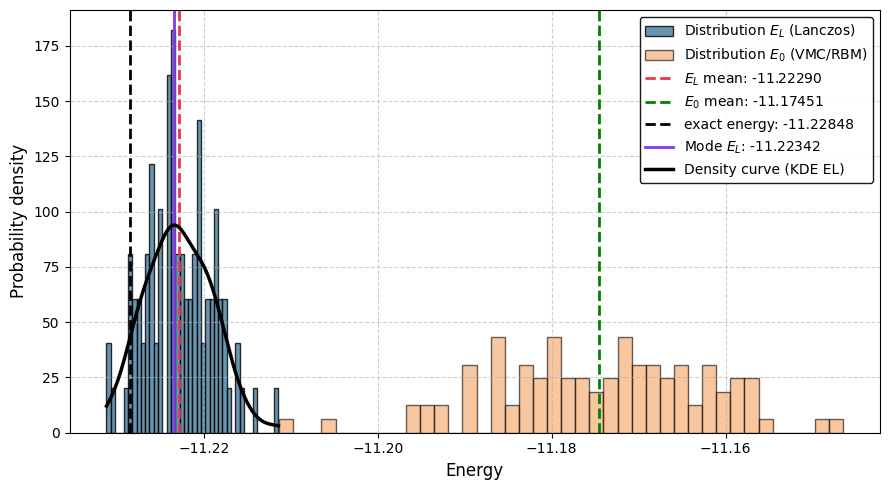

In [ ]:
plot_energy_distribution(
    el_valides=results_eL, 
    results_e0=results_e0, 
    exact_gs_energy=exact_gs_energy, 
    data_file=data_file,
    bins=40 
)

Graphique d'extrapolation sauvegardé sous : ../../datas/2D_4x4/datas_alpha_iter_200/extrapolation_plot.png


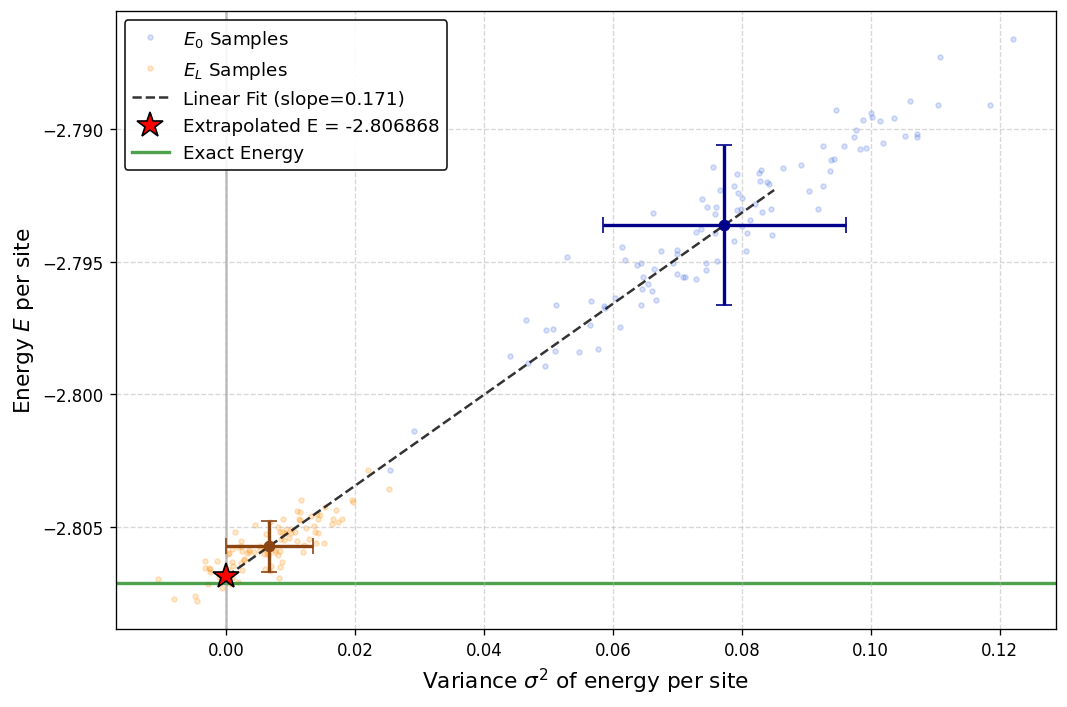


--- Extrapolation Results (per site) ---
Extrapolated Energy (x=0) : -2.80686834
Exact Energy              : -2.80712080
Absolute Error            : 2.52457534e-04
----------------------------------------



In [ ]:
plot_zero_variance_extrapolation(
    results_e0 = results_e0, 
    results_sigma_e0 = results_sigma_e0, 
    el_valides = results_eL, 
    results_sigma_eL = results_sigma_eL, 
    exact_gs_energy = exact_gs_energy, 
    L = L, 
    data_file = data_file
)